In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
def get_data(path: str):
    data = np.load(path, allow_pickle=True)

    meta = data["meta"].item()
    config = meta["config"]
    #print(config)

    qtm_traj = data["quantum_traj"].item()
    qtm_F = qtm_traj["F"]
    qtm_rho = qtm_traj["rho"]
    qtm_u = qtm_traj["u"]

    cls_traj = data["classical_traj"].item()
    cls_F = cls_traj["F"]
    cls_rho = cls_traj["rho"]
    cls_u = cls_traj["u"]

    return config, qtm_rho, qtm_u, cls_rho, cls_u

In [3]:
path_list = [
    "lbm_cylinder_20251124_154409.npz",
    "lbm_cylinder_20251126_110021.npz",
    "lbm_cylinder_20251126_113541.npz",]

config_dict = {}
qtm_rho_dict = {}
qtm_u_dict = {}
cls_rho_dict = {}
cls_u_dict = {}

for path in path_list:
    config, qtm_rho, qtm_u, cls_rho, cls_u = get_data(path)
    config_dict[config['u0'][0]] = config
    qtm_rho_dict[config['u0'][0]] = qtm_rho
    qtm_u_dict[config['u0'][0]] = qtm_u
    cls_rho_dict[config['u0'][0]] = cls_rho
    cls_u_dict[config['u0'][0]] = cls_u

In [4]:
def compute_errors(u0x):
    config = config_dict[u0x]
    qtm_rho = qtm_rho_dict[u0x]
    qtm_u = qtm_u_dict[u0x]
    cls_rho = cls_rho_dict[u0x]
    cls_u = cls_u_dict[u0x]

    ## Unweighted Velocity error
    vel_er = np.linalg.norm(qtm_u - cls_u, axis=-1)
    cls_vel = np.linalg.norm(cls_u, axis=-1)
    vel_rel = np.sum(vel_er, axis=(1,2)) / (np.sum(cls_vel, axis=(1,2)))

    ## Density (Scalar) error
    rho_er = abs(qtm_rho - cls_rho)
    rho_rel = np.sum(rho_er, axis=(1, 2)) / np.sum(abs(cls_rho), axis=(1, 2))

    return vel_rel, rho_rel

In [5]:
T = 10001

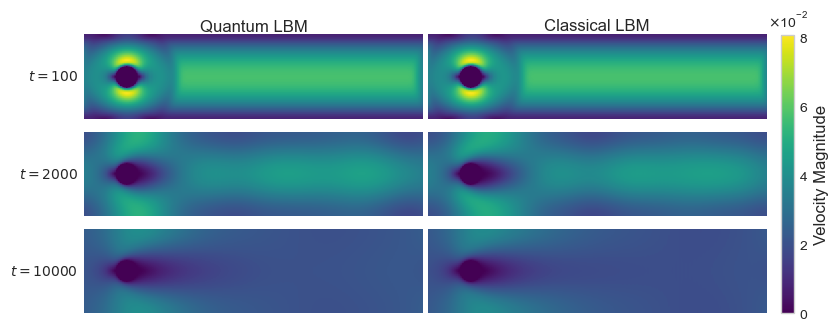

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter

qtm_rho, qtm_u = qtm_rho_dict[0.019245008972987525], qtm_u_dict[0.019245008972987525]
cls_rho, cls_u = cls_rho_dict[0.019245008972987525], cls_u_dict[0.019245008972987525]

times = [100, 2000, 10000]

fig, axs = plt.subplots(nrows=len(times), ncols=2, figsize=(7.1, 2.9), constrained_layout=False)
# small but visible gaps, tuned for this geometry
fig.subplots_adjust(left=0.0, right=1, top=1, bottom=0.0, wspace=0.015, hspace=0.02)


# Global color scaling (mandatory for comparison)
qtm_norm = np.linalg.norm(qtm_u, axis=-1)
cls_norm = np.linalg.norm(cls_u, axis=-1)
vmin = min(qtm_norm.min(), cls_norm.min())
vmax = max(qtm_norm.max(), cls_norm.max())

for i, t in enumerate(times):
    im = axs[i, 0].imshow(
        np.linalg.norm(qtm_u[t // 20], axis=-1),
        cmap='viridis', vmin=vmin, vmax=vmax,
        interpolation='nearest',
        aspect='equal',
    )
    axs[i, 0].axis('off')

    axs[i, 1].imshow(
        np.linalg.norm(cls_u[t // 20], axis=-1),
        cmap='viridis', vmin=vmin, vmax=vmax,
        interpolation='nearest',
        aspect='equal',
    )
    axs[i, 1].axis('off')

# Column headers
axs[0, 0].set_title("Quantum LBM", fontsize=12, pad=3)
axs[0, 1].set_title("Classical LBM", fontsize=12, pad=3)

# Row labels (left only)
for i, t in enumerate(times):
    axs[i, 0].text(
        -0.02, 0.5,
        rf"$t={t}$", #sci_time_label(t),
        transform=axs[i, 0].transAxes,
        ha='right', va='center',
        fontsize=10
    )

# Colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.0196, pad=0.02)
cbar.set_label("Velocity Magnitude", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Scientific notation as offset text (×10^{-2}) at the top
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, -2))   # force 10^{-2}
cbar.formatter = formatter
cbar.update_ticks()
cbar.set_ticks([0, 2e-2, 4e-2, 6e-2, 8e-2])

# ---- FIX POSITION OF OFFSET TEXT ----
offset_text = cbar.ax.yaxis.get_offset_text()
offset_text.set_fontsize(10)
offset_text.set_ha('center')
offset_text.set_va('bottom')
offset_text.set_x(0.5)     # center horizontally over the colorbar
offset_text.set_y(1.02)    # slightly above the colorbar

plt.savefig("cylinder_field_hor.pdf", format="pdf", bbox_inches="tight")
plt.show()


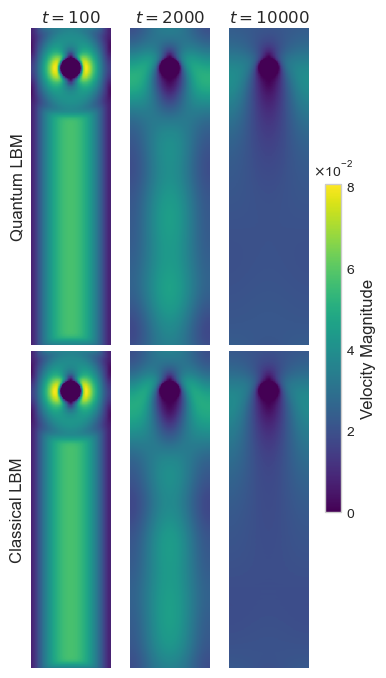

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- Data selection ---
nu = 0.019245008972987525
qtm_rho, qtm_u = qtm_rho_dict[nu], qtm_u_dict[nu]
cls_rho, cls_u = cls_rho_dict[nu], cls_u_dict[nu]

times = [100, 2000, 10000]  # columns

# --- Figure: 2 rows (QLBM / CLBM) x len(times) cols (time) ---
fig, axs = plt.subplots(
    nrows=2,
    ncols=len(times),
    figsize=(4., 8),          # tuned for double-column readability with rotated tall panels
    constrained_layout=False
)

# Spacing: small but visible (not glued)
fig.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.10, wspace=0.02, hspace=0.02)

# --- Global color scaling for fair comparison ---
qtm_norm = np.linalg.norm(qtm_u, axis=-1)
cls_norm = np.linalg.norm(cls_u, axis=-1)
vmin = min(qtm_norm.min(), cls_norm.min())
vmax = max(qtm_norm.max(), cls_norm.max())

# --- Plot panels (rotate by -90 degrees = k=3) ---
for j, t in enumerate(times):
    # QLBM row (row 0)
    im = axs[0, j].imshow(
        np.rot90(np.linalg.norm(qtm_u[t // 20], axis=-1), k=3),
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        interpolation='nearest'
    )
    axs[0, j].axis('off')

    # CLBM row (row 1)
    axs[1, j].imshow(
        np.rot90(np.linalg.norm(cls_u[t // 20], axis=-1), k=3),
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        interpolation='nearest'
    )
    axs[1, j].axis('off')

    # Column title = time (top row only)
    axs[0, j].set_title(rf"$t={t}$", fontsize=12, pad=4)

# Row labels (left side only, once per row)
axs[0, 0].text(-0.08, 0.5, "Quantum LBM", transform=axs[0, 0].transAxes,
              ha='right', va='center', fontsize=12, rotation=90)
axs[1, 0].text(-0.08, 0.5, "Classical LBM", transform=axs[1, 0].transAxes,
              ha='right', va='center', fontsize=12, rotation=90)

# --- Shared colorbar (spans all subplots) ---
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.05, pad=0.05)
cbar.set_label("Velocity Magnitude", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Force ×10^{-2} as offset text on top
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, -2))
cbar.formatter = formatter
cbar.update_ticks()

# Center the offset text exactly above the colorbar
offset_text = cbar.ax.yaxis.get_offset_text()
offset_text.set_fontsize(10)
offset_text.set_ha('center')
offset_text.set_va('bottom')
offset_text.set_x(0.5)
offset_text.set_y(1.02)

# Only ticks: 0, 2, 4, 6, 8 (×10^{-2})
cbar.set_ticks([0, 2e-2, 4e-2, 6e-2, 8e-2])

plt.savefig("cylinder_field_ver.pdf", format="pdf", bbox_inches="tight")
plt.show()


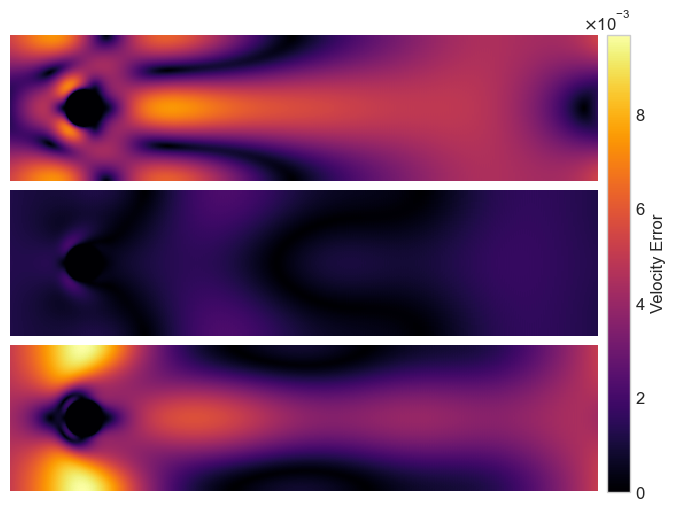

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup ---
cls_rho, cls_u = cls_rho_dict[0.019245008972987525], cls_u_dict[0.019245008972987525]
keys = sorted(list(config_dict.keys()))

numeric_label = [int(np.round(3 * u0x / (0.1/np.sqrt(3)))) for u0x in keys]
str_label = []
for n in numeric_label:
    if n == 0:
        str_label.append(r"$\mathbf{\hat u}=(0,0)$")
    elif n == 1:
        str_label.append(r"$\mathbf{\hat u}=(u_0/3,0)$")
    else:
        str_label.append(rf"$\mathbf{{\hat u}}=({n}u_0/3,0)$")

# --- 2. Global scaling for consistent colors ---
max_errors = []
for key in keys:
    err = np.linalg.norm(qtm_u_dict[key][-1] - cls_u[-1], axis=-1)
    max_errors.append(np.max(err))
vmax_val = float(np.max(max_errors))

# --- 3. Plot: 3 subplots stacked vertically (horizontal strips) ---
fig, axs = plt.subplots(3, 1, figsize=(8, 5), constrained_layout=True)

cmap_choice = 'inferno'

for i, key in enumerate(keys[:3]):  # ensure exactly 3 panels
    qtm_u = qtm_u_dict[key]
    error_field = np.linalg.norm(qtm_u[-1] - cls_u[-1], axis=-1)

    im = axs[i].imshow(
        error_field,
        cmap=cmap_choice,
        vmin=0,
        vmax=vmax_val,
        interpolation='nearest'
    )

    # Put the text to the left
    #axs[i].set_ylabel(str_label[i], fontsize=12, rotation=0, labelpad=5, va='center', ha='right')

    # Hide ticks and spines instead of using axis('off') so the ylabel remains visible
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    for spine in axs[i].spines.values():
        spine.set_visible(False)

# --- 4. Shared Colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.0407, pad=-0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Velocity Error", fontsize=12)

# Force ×10^{-3} as offset text on top
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
cbar.formatter = formatter
cbar.update_ticks()

cbar.ax.yaxis.get_offset_text().set_fontsize(12)
cbar.ax.tick_params(labelsize=12)

plt.savefig("cylinder_heatmap_hor.pdf", format="pdf", bbox_inches="tight")
plt.show()

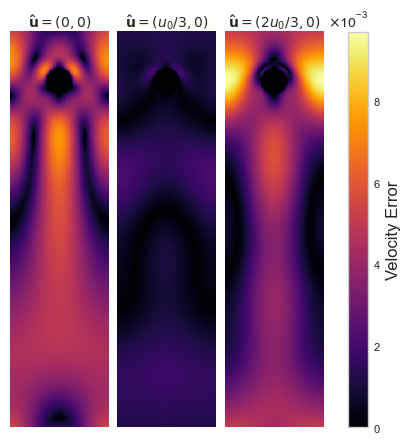

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup ---
cls_rho, cls_u = cls_rho_dict[0.019245008972987525], cls_u_dict[0.019245008972987525]
keys = sorted(list(config_dict.keys()))

numeric_label = [int(np.round(3 * u0x / (0.1/np.sqrt(3)))) for u0x in keys]
str_label = []
for n in numeric_label:
    if n == 0:
        str_label.append(r"$\mathbf{\hat u}=(0,0)$")
    elif n == 1:
        str_label.append(r"$\mathbf{\hat u}=(u_0/3,0)$")
    else:
        str_label.append(rf"$\mathbf{{\hat u}}=({n}u_0/3,0)$")


# --- 2. Global scaling for consistent colors ---
max_errors = []
for key in keys:
    err = np.linalg.norm(qtm_u_dict[key][-1] - cls_u[-1], axis=-1)
    max_errors.append(np.max(err))
vmax_val = float(np.max(max_errors))

# --- 3. Plot: 3 rotated subplots in a single row ---
fig, axs = plt.subplots(1, 3, figsize=(4, 5), constrained_layout=True)
#fig.subplots_adjust(left=0.03, right=0.995, top=0.88, bottom=0.18, wspace=0.08)

cmap_choice = 'inferno'

for i, key in enumerate(keys[:3]):  # ensure exactly 3 panels
    qtm_u = qtm_u_dict[key]
    error_field = np.linalg.norm(qtm_u[-1] - cls_u[-1], axis=-1)

    # rotate by -90 degrees => k=3
    error_field_rot = np.rot90(error_field, k=3)

    im = axs[i].imshow(
        error_field_rot,
        cmap=cmap_choice,
        vmin=0,
        vmax=vmax_val,
        interpolation='nearest'
    )

    axs[i].set_title(str_label[i], fontsize=10, pad=3)
    axs[i].axis('off')

# --- 4. Shared Colorbar (horizontal) ---
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.063, pad=0.015)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Velocity Error", fontsize=12)

# Force ×10^{-3} as offset text on top
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
cbar.formatter = formatter
cbar.update_ticks()

plt.savefig("cylinder_heatmap_ver.pdf", format="pdf", bbox_inches="tight")
plt.show()


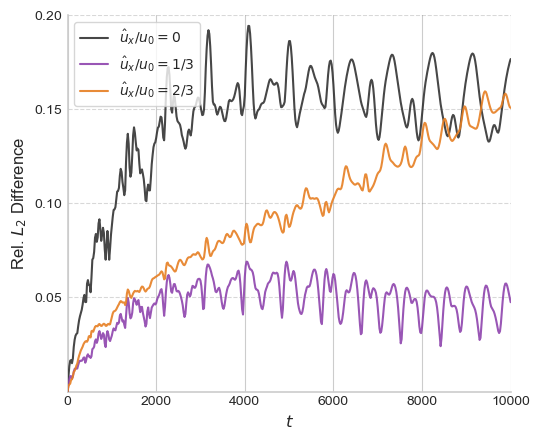

In [203]:
fig, ax = plt.subplots(figsize=(5.5, 4.5)) # dpi=150 makes it crisp for screens

# 2. Spines: Instead of coloring them gray, remove top/right entirely
# This is the standard "Tufte" minimalist style for scientific plots
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 3. Axis Formatting
ax.set_xlim(0, 10000)
ax.set_ylim(0, 0.2)

# Force Scientific Notation (e.g., 1.5 x 10^-3) to clean up the Y-axis labels
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(10)

ax.set_yticks(np.array([0.05, 0.1, 0.15, 0.2]))

ax.tick_params(axis='both', labelsize=10)

# 4. Grid: A subtle horizontal grid helps read amplitude without clutter
ax.grid(visible=True, axis='y', linestyle='--', alpha=0.3, color='gray')

# 5. Plotting
# 'zorder' ensures lines are drawn on top of the grid
# 'alpha' on the black line softens it slightly so it's not too harsh
times = np.arange(0,T,20)
colors = ['#333333', '#8E44AD', '#E67E22']

keys = sorted(list(config_dict.keys()))
numeric_label = [int(np.round(3 * u0x / (0.1/np.sqrt(3)))) for u0x in keys]
fraction_label = [str(n) + '/3' if n != 0 else '0' for n in numeric_label]
#str_label = [f"$\hat u_{{x}}/u_0 = {frac}$" for frac in fraction_label]
str_label = [f"$\hat u_{{x}}/u_0 = {frac}$" for frac in fraction_label]
#'$u_{0}/u_{\\text{max}} =$' + f"{int(np.round(3 * config['u0'][0] / (0.1/np.sqrt(3))))} / 3"

for i,u0x in enumerate(keys):
    config = config_dict[u0x]
    vel_rel, rho_rel = compute_errors(u0x)
    ax.plot(times, vel_rel, label=str_label[i], linewidth=1.5, color=colors[i], alpha=0.9, zorder=3)

# 6. Labels and Legend
ax.set_xlabel('$t$', fontsize=12)
ax.set_ylabel('Rel. $L_2$ Difference', fontsize=12)

# "frameon=False" removes the box around the legend for a cleaner look
ax.legend(loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig("cylinder_error.pdf", format="pdf", bbox_inches="tight")

plt.show()